# 2 — REDSEA pixel-level spillover correction

Corrects lateral marker spillover across shared cell boundaries: rasterize the QuPath GeoJSON to an int32
mask, sum each qptiff channel per cell and per 1-px boundary band, build an 8-connected contact graph, and
apply `corrected = clip(data - alpha*(F@edge))` (subtract-only, alpha=1, 1-px band).

**Begin with the diagnostics** (a before/after look at the correction *in tissue*), then run REDSEA on the
chosen donors.

In [2]:
# Parameters for this step (self-contained -- no config.ini). Edit the paths for your machine.
# %load_ext autoreload
# %autoreload 2                                         # pick up edits to the phenocycler package without a kernel restart
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # make `phenocycler` importable from notebooks/
from phenocycler import PipelineConfig

REPO = pathlib.Path.cwd().resolve().parents[1]        # Islet-Explorer-Senior (parent of the submodule; data/ lives here)

# Run on a subset of donors (None = every donor under data/cells/donor_id=*).
DONORS = ["6374"]            # e.g. ["6374", "6380"] to iterate on a few

# REDSEA before/after diagnostic display (see phenocycler.spatial.plot_redsea_before_after)
DISPLAY_MARKER = "auto"  # "auto" (per-cell largest |delta|) | "Pan_Cytokeratin" | ["auto", "INS"]
ROW_MODE       = "both"  # "both" | "cell" (per-cell tight zoom) | "marker" (islet field across markers)
DAPI_PCT       = 90      # drop cells above this raw-DAPI pctile from the exemplars (nucleus-dominated
                         # segmentations read as DAPI-bright, poor whole-cell exemplars); 100 = keep all

cfg = PipelineConfig(
    data_dir   = REPO / "data",
    images_dir = pathlib.Path("/home/smith6jt/IO60panc2nd/Images"),
    # --- REDSEA parameters (this step) ---
    redsea_downsample  = 1.0,    # must be a power of 2
    redsea_edge_radius = 0,      # 0 = the 1-px cell rim
    redsea_comp_mode   = 0,      # 0 = subtract-only (1 = subtract+reinforce)
    redsea_alpha       = 1.0,    # spillover subtraction strength
    redsea_gap_bridge  = 1,      # bridge background gaps <= N px in the contact graph
    # --- compute ---
    n_jobs  = 8,                 # per-donor process pool (donors are independent)
    use_gpu = False,             # opt-in CuPy backend (use with n_jobs=1)
)
donors = DONORS or cfg.discover_donors()
print(f"donors: {len(donors)} " + ("(subset)" if DONORS else "(all)") + f" -> {donors[:6]}" + (" ..." if len(donors) > 6 else ""))

donors: 1 (subset) -> ['6374']


## Diagnostics — REDSEA before/after (begin here)

The segmentation masks are drawn over the marker channel and each cell is filled by its **raw (before)** vs
**REDSEA (after)** mean and their **Δ**, for the most- vs least-changed cells: a dim cell losing a bright
neighbour's bleed = large Δ; an isolated / uniform cell = Δ≈0. Needs the per-donor OME-TIFF (`ome_dir`) +
instance mask (`cfg.mask_dir/<donor>.tif`); **falls back** to the raw-vs-corrected scatter/hist otherwise.
The scatter/hist correlation plot is also drawn explicitly in the next cell (always available). Runs on the
first (subset) donor — this is a look at an EXISTING `cells_redsea/`, so run the REDSEA cell below first if
it is empty.

6374: px_um=0.5078  OME levels=6
  loaded 2,533,150 cells x 59 markers in 7.7s
  MOST : [('INS', 22486), ('GCG', 20354), ('GCG', 20140)]
  LEAST: [2345.1, 2442.1]
  saved /home/smith6jt/IO60panc2nd/Islet-Explorer-Senior/figures/6374_redsea_before_after_cells.png


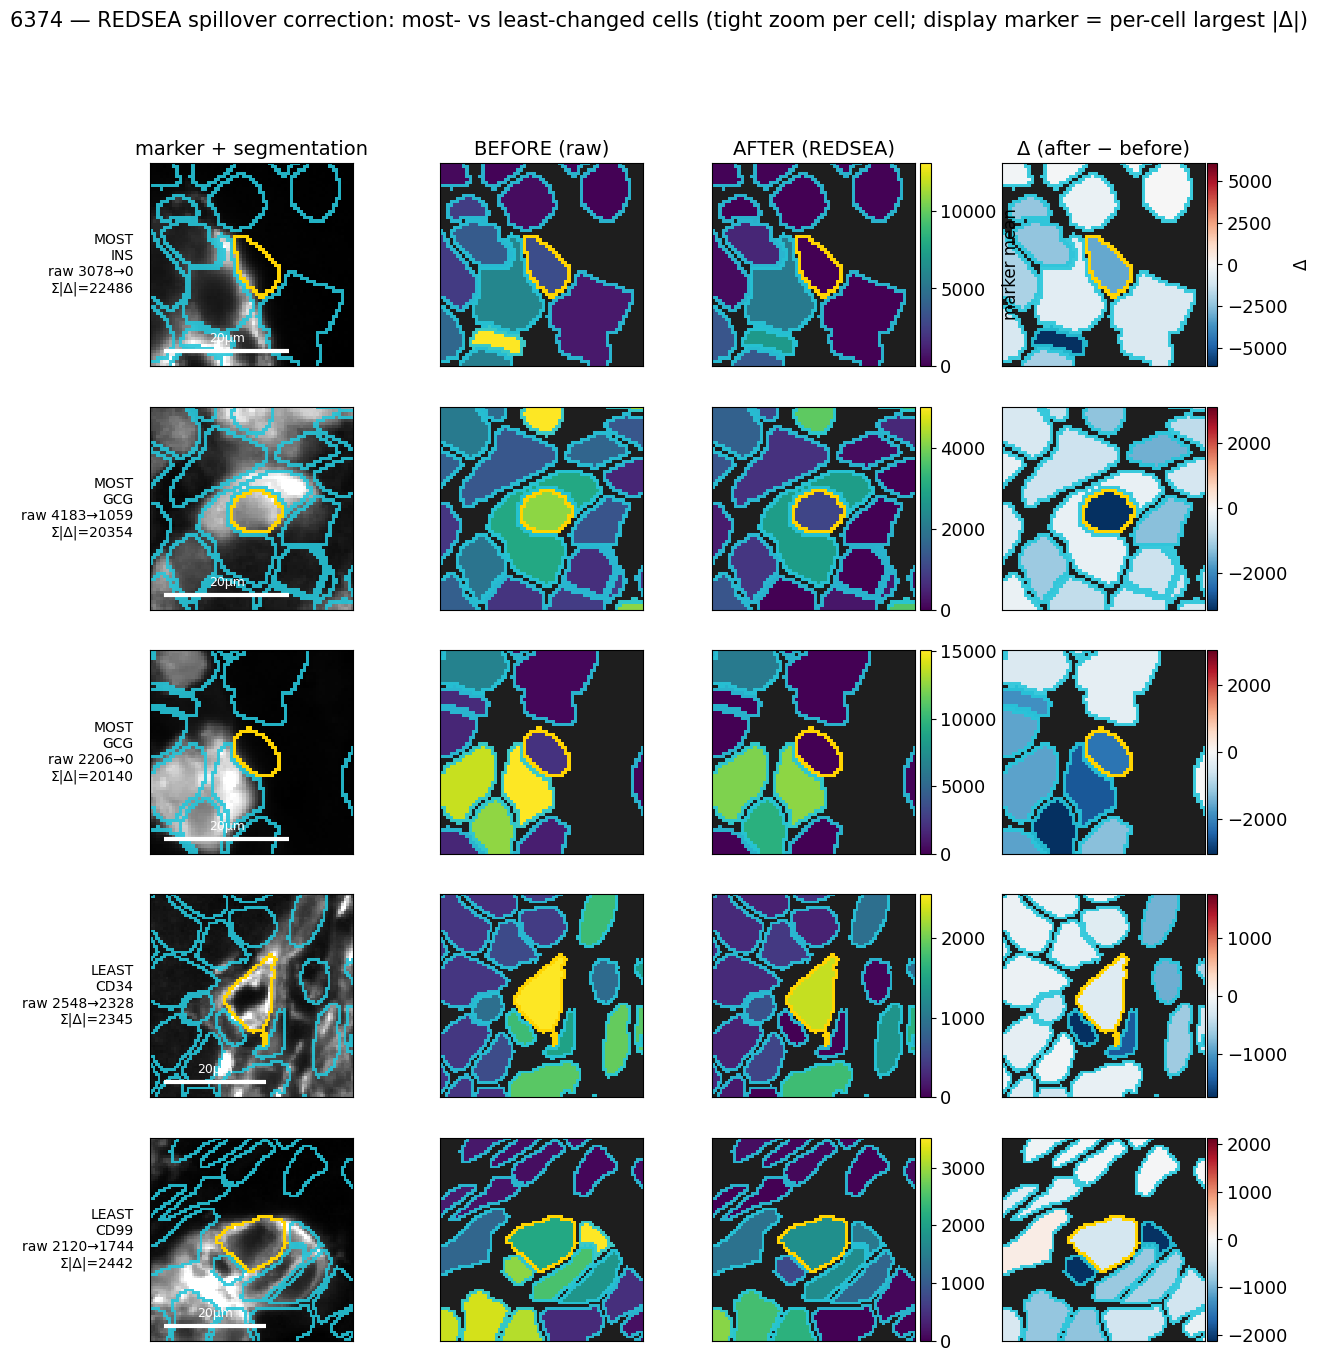

  saved /home/smith6jt/IO60panc2nd/Islet-Explorer-Senior/figures/6374_redsea_before_after_markers.png


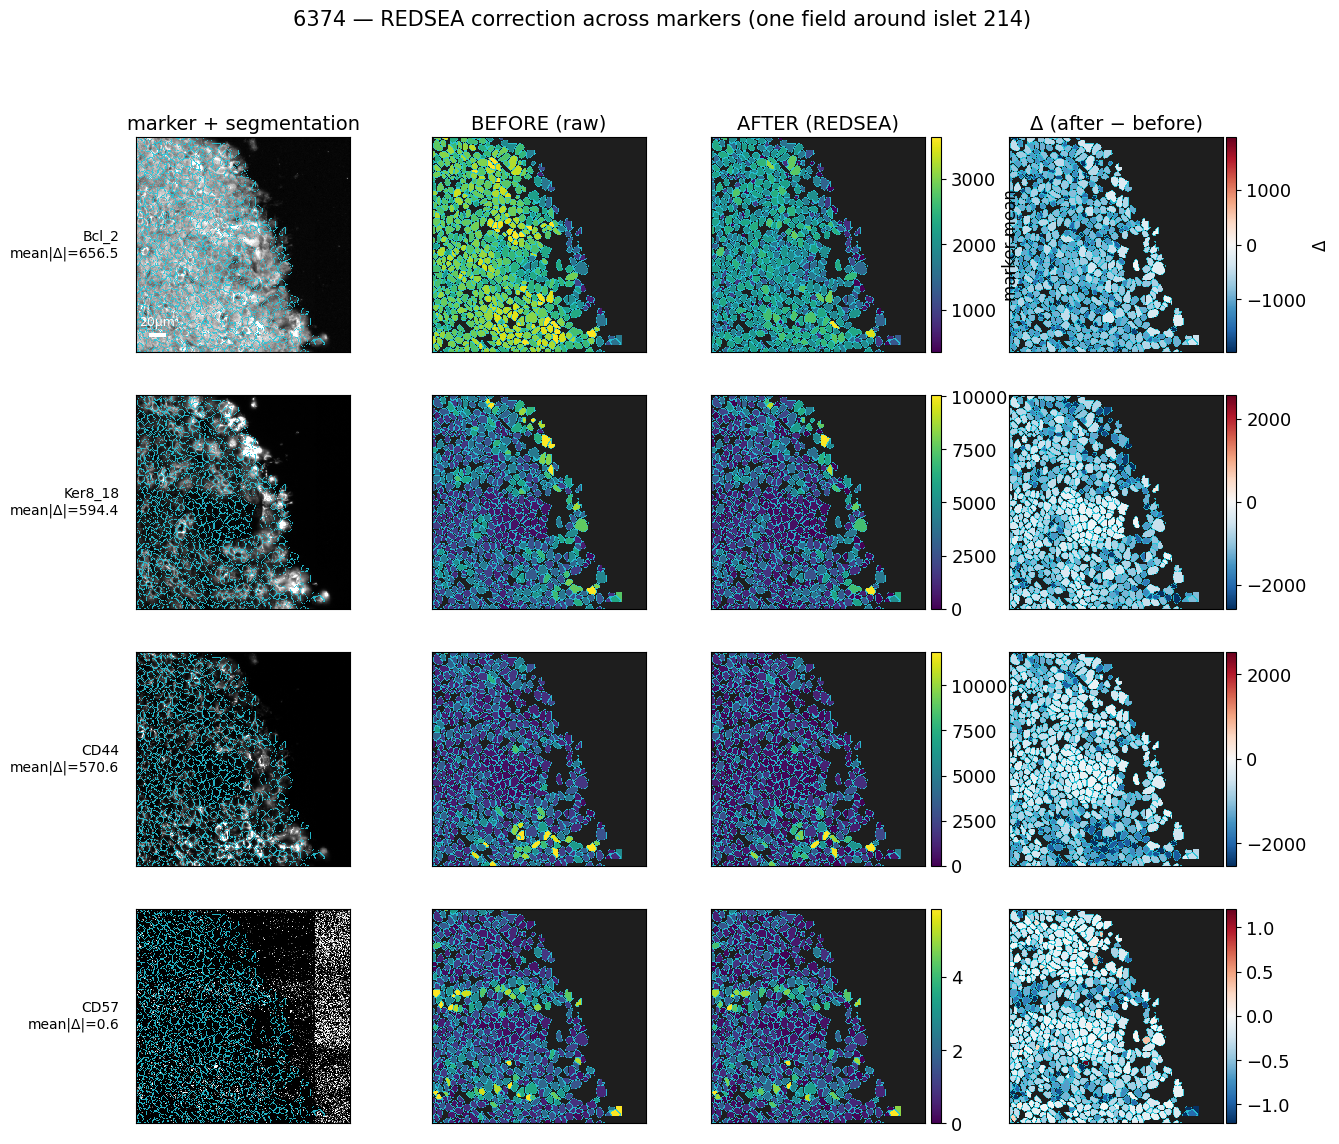

In [3]:
%matplotlib inline
from phenocycler.spatial import plot_redsea_before_after
plot_redsea_before_after(cfg, donors[0], display_marker=DISPLAY_MARKER, row_mode=ROW_MODE, dapi_pct=DAPI_PCT)

### Alignment check — corrected means track the raw QuPath means

The raw-vs-REDSEA **correlation scatter** + **distribution-shift histogram** for one marker (default
`Pan_Cytokeratin`), joined on `object_id` (never coordinates), plus the Pearson r. Corrected ≤ raw because
spillover is subtracted; lightly-affected markers stay at r ≈ 0.99+, while heavily-corrected markers
(`Pan_Cytokeratin`, `Vimentin`) decorrelate more as more spillover is removed — that is the correction
working, not an error. Pass `marker="INS"` to inspect another channel.

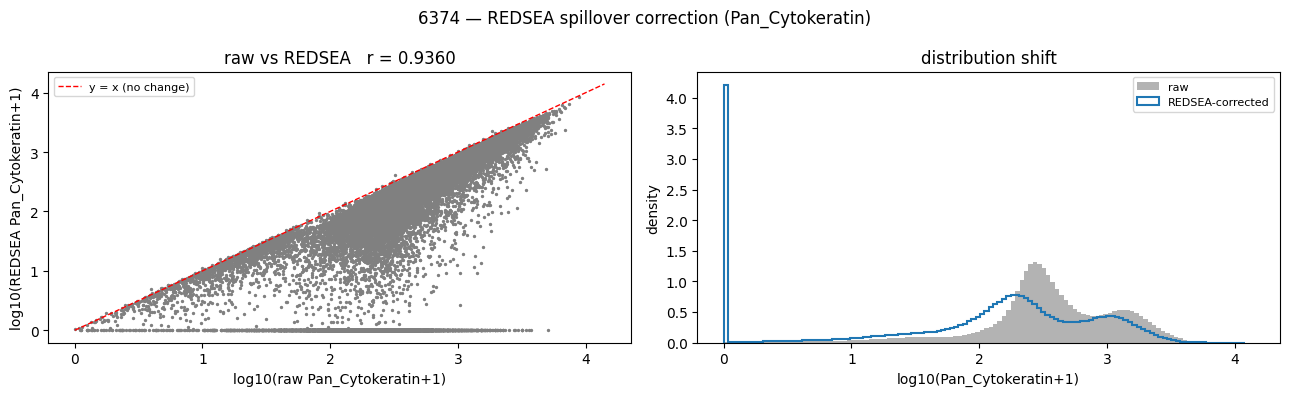

Pan_Cytokeratin: raw 645.3 -> REDSEA 398.0   r=0.9360   99.5% of cells corrected <= raw


In [4]:
%matplotlib inline
from phenocycler.spatial import plot_redsea_scatter_hist
from IPython.display import Image, display

plot_redsea_scatter_hist(cfg, donors[0])            # scatter + hist + Pearson r (marker=None -> Pan_Cytokeratin)

# Committed cross-compartment co-positive-collapse figure (redsea_full_validate.py), if present.
fig = cfg.data_dir / "redsea_full_validation.png"
if fig.exists():
    display(Image(filename=str(fig)))

## Run — REDSEA on the (subset of) donors

Two validated defaults: **subtract-only** (`comp_mode=0`) and a thin **1-px band** (`edge_radius=0`) with
`alpha=1`. Every donor is independent (`n_jobs`); the optional CuPy backend accelerates the per-channel
`bincount` + sparse `F@edge` (use with `n_jobs=1`). Or use the SLURM array `scripts/slurm/02_redsea_array.sh`.

In [4]:
from phenocycler.redsea import run_redsea, RedseaParams
params = RedseaParams.from_config(cfg)
print(f"comp_mode={params.comp_mode} alpha={params.alpha} edge_radius={params.edge_radius} "
      f"gap_bridge={params.gap_bridge} gpu={params.use_gpu}")
# Smoke-test one donor first if you like:  run_redsea(cfg, donors[:1], params, n_jobs=1)
run_redsea(cfg, donors, params, n_jobs=cfg.n_jobs)   # `donors` respects the DONORS subset

comp_mode=0 alpha=1.0 edge_radius=0 gap_bridge=1 gpu=False
[6374] image=6374_Scan1.er.qptiff - resolution #1
[6374] level=0 dims=51120x35520 channels=59 px_um=0.5077663810243286 gpu=False
  [raster] loading cells__6374_Scan1.er.qptiff_-_resolution__1.geojson ...
  [raster] 100,000/2,533,150 (8s)
  [raster] 200,000/2,533,150 (16s)
  [raster] 300,000/2,533,150 (24s)
  [raster] 400,000/2,533,150 (33s)
  [raster] 500,000/2,533,150 (41s)
  [raster] 600,000/2,533,150 (49s)
  [raster] 700,000/2,533,150 (57s)
  [raster] 800,000/2,533,150 (66s)
  [raster] 900,000/2,533,150 (74s)
  [raster] 1,000,000/2,533,150 (82s)
  [raster] 1,100,000/2,533,150 (91s)
  [raster] 1,200,000/2,533,150 (99s)
  [raster] 1,300,000/2,533,150 (108s)
  [raster] 1,400,000/2,533,150 (116s)
  [raster] 1,500,000/2,533,150 (124s)
  [raster] 1,600,000/2,533,150 (132s)
  [raster] 1,700,000/2,533,150 (141s)
  [raster] 1,800,000/2,533,150 (150s)
  [raster] 1,900,000/2,533,150 (159s)
  [raster] 2,000,000/2,533,150 (168s)
  [raste

['6374']